# Data preparation

Downloads every dataset YourMT3+ fine-tuning needs into Google Drive
(`DATA_HOME`), idempotently — anything already present is skipped:

- **Reference sets** (forgetting mitigation): EGMD, MAESTRO, Slakh — YourMT3's
  pre-processed 16 kHz archives.
- **Electronic** (Track B): **NES-MDB** (labeled chiptune, real 2A03 timbre) and
  **MetaMIDI** (genre-tagged MIDI feedstock for the real-synth renderer).

It also shows the on-disk format YourMT3+ loads and checks the train/validation/
test split (repo-level: held-out test authors).

In [1]:
# Environment: Colab (Drive-mounted) or local checkout.
import json, os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = Path("/content/drive/MyDrive/restrudel")
    DATA_HOME = DRIVE / "datasets"           # durable store (same layout sync_drive.sh pushes to)
    SCRATCH = Path("/content/scratch")       # fast ephemeral disk for download+extract
    if not Path("/content/restrudel").exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/henrik253/Restrudel.git", "/content/restrudel"], check=True)
    REPO = Path("/content/restrudel")
    # Installer deps found by tracing install_dataset's import chain; mirdata is
    # pinned: 0.3.9+ removed jams_utils which their slakh16k loader imports.
    %pip -q install huggingface_hub mido "mirdata==0.3.8" pretty_midi mir_eval torchmetrics deprecated smart_open
else:
    REPO = Path(os.environ.get("RESTRUDEL_REPO", Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
    DATA_HOME = Path(os.environ.get("RESTRUDEL_DATA_HOME", REPO / "datasets"))
    SCRATCH = DATA_HOME  # locally, download straight into place

SCRATCH.mkdir(parents=True, exist_ok=True)
DATA_HOME.mkdir(parents=True, exist_ok=True)
INDEX_DIR = DATA_HOME / "yourmt3_indexes"
print(f"colab={IN_COLAB}\nrepo={REPO}\ndata_home={DATA_HOME}")

colab=False
repo=/Users/henrik/Documents/Informatik/Master/restrudel/.claude/worktrees/corpus-holdout-regen
data_home=/Users/henrik/Documents/Informatik/Master/restrudel/datasets


In [ ]:
# which datasets to fetch this run (idempotent: present sets are skipped)
DOWNLOAD = {
    "egmd":     False,  # ~22 GB electronic drums (closest existing set to our domain)
    "maestro":  False,  # ~19 GB piano — cheap pitched replay
    "slakh":    False,  # ~30 GB band mixes — main forgetting-mitigation set
    "nesmdb":   False,  # chiptune: real 2A03 timbre + note labels (Track B B3)
    "metamidi": False,  # genre-tagged MIDI feedstock -> render_synths.py (no audio)
}

## 1. The format YourMT3+ expects

Every dataset is converted once into this layout under `DATA_HOME`:

```
<dataset>_yourmt3_16k/<song>/
    mix.wav                  16 kHz MONO 16-bit PCM  (the model's input format)
    <song>_notes.npy         {'notes': [Note, ...]}        pickled
    <song>_note_events.npy   {'note_events': [NoteEvent]}  pickled (tokenizer input)
yourmt3_indexes/<dataset>_{train,validation,test}_file_list.json   (what the loader opens)
```

A `Note` (amt/src/utils/note_event_dataclasses.py) carries `is_drum`, `program`
(GM 0–127, or 128 for drums), `onset`/`offset` in **seconds**, `pitch`, and a
binary `velocity`. `NoteEvent` is the same flattened into an onset/offset stream.

In [3]:
# YourMT3's code (amt/src) is needed to unpickle Note/NoteEvent and to run installers.
# Code-only fetch (~few MB) — the 536 MB checkpoint is NOT needed for data work.
AMT_SRC = Path(os.environ.get("RESTRUDEL_AMT_SRC", REPO / "models" / "YourMT3" / "amt" / "src"))
if not AMT_SRC.exists():
    from huggingface_hub import snapshot_download
    snapshot_download(repo_id="mimbres/YourMT3", repo_type="space",
                      allow_patterns=["amt/src/**"], local_dir=AMT_SRC.parents[1])
sys.path.insert(0, str(AMT_SRC))
print("amt/src:", AMT_SRC)

amt/src: /Users/henrik/Documents/Informatik/Master/restrudel/models/YourMT3/amt/src


In [4]:
# Format demo on a real song (first Strudel song found in Drive/DATA_HOME).
import numpy as np, wave

demo = sorted((DATA_HOME / "strudel_yourmt3_16k").glob("*/")) if (DATA_HOME / "strudel_yourmt3_16k").exists() else []
if not demo:
    print("no Strudel data in DATA_HOME yet — run preprocess_strudel.py locally and sync_drive.sh push")
else:
    d = demo[0]; sid = d.name
    notes = np.load(d / f"{sid}_notes.npy", allow_pickle=True).item()
    nev = np.load(d / f"{sid}_note_events.npy", allow_pickle=True).item()
    with wave.open(str(d / "mix.wav")) as w:
        print(f"{sid}: mix.wav {w.getframerate()} Hz, {w.getnchannels()} ch, {w.getnframes()/w.getframerate():.1f} s")
    print("programs:", notes["program"], " is_drum:", notes["is_drum"], " duration:", notes["duration_sec"], "s")
    print("first 3 Notes:      ", *notes["notes"][:3], sep="\n  ")
    print("first 3 NoteEvents: ", *nev["note_events"][:3], sep="\n  ")
    fl = json.load(open(INDEX_DIR / "strudel_train_file_list.json"))
    print("\nindex entry 0:", json.dumps(fl["0"], indent=2)[:500])

corpus_0002bbc4d6: mix.wav 16000 Hz, 1 ch, 18.0 s
programs: [128]  is_drum: [1]  duration: 16 s
first 3 Notes:      
  Note(is_drum=True, program=128, onset=0, offset=0.01, pitch=36, velocity=1)
  Note(is_drum=True, program=128, onset=0, offset=0.01, pitch=42, velocity=1)
  Note(is_drum=True, program=128, onset=0.333333, offset=0.343333, pitch=42, velocity=1)
first 3 NoteEvents: 
  NoteEvent(is_drum=True, program=128, time=0, velocity=1, pitch=36, activity=set())
  NoteEvent(is_drum=True, program=128, time=0, velocity=1, pitch=42, activity=set())
  NoteEvent(is_drum=True, program=128, time=0.333333, velocity=1, pitch=42, activity=set())

index entry 0: {
  "strudel_id": "corpus_5bd2ab7e90",
  "n_frames": 288000,
  "mix_audio_file": "/Users/henrik/Documents/Informatik/Master/restrudel/datasets/strudel_yourmt3_16k/corpus_5bd2ab7e90/mix.wav",
  "notes_file": "/Users/henrik/Documents/Informatik/Master/restrudel/datasets/strudel_yourmt3_16k/corpus_5bd2ab7e90/corpus_5bd2ab7e90_notes.npy",
  

## 2. Download datasets → Drive

Each enabled set downloads/extracts on fast scratch, runs its indexer, and moves
the result into Drive; re-runs skip anything present. Reference sets use YourMT3's
pre-processed archives; NES-MDB and MetaMIDI use the Track B preparers
(`scripts/dataset/prepare_{nesmdb,metamidi}.py`). MetaMIDI is MIDI only — its
audio comes later from the real-synth renderer (`render_synths.py`).

In [ ]:
def dataset_present(name: str) -> bool:
    if name == "metamidi":
        return (DATA_HOME / "metamidi_electronic").exists()
    return any(INDEX_DIR.glob(f"{name}*_file_list.json"))

def move_into_drive(src_home: Path, name_hints: list):
    """Move freshly built dataset dirs + index files from scratch into DATA_HOME."""
    if src_home == DATA_HOME:
        return
    for p in src_home.iterdir():
        if p.name == "yourmt3_indexes":
            INDEX_DIR.mkdir(exist_ok=True)
            for f in p.iterdir():
                shutil.move(str(f), INDEX_DIR / f.name)
        elif any(h in p.name for h in name_hints):
            shutil.move(str(p), DATA_HOME / p.name)

def cmd_for(name: str):
    S = REPO / "scripts" / "dataset"
    common = ["--data-home", str(SCRATCH), "--amt-src", str(AMT_SRC)]
    if name in ("egmd", "maestro", "slakh"):
        return [sys.executable, str(S / "install_reference_sets.py"), "--sets", name] + common
    if name == "nesmdb":
        return [sys.executable, str(S / "prepare_nesmdb.py"), "--download"] + common
    if name == "metamidi":
        return [sys.executable, str(S / "prepare_metamidi.py"), "--data-home", str(SCRATCH)]
    raise ValueError(name)

for name, enabled in DOWNLOAD.items():
    if not enabled:
        print(f"[skip] {name}: disabled in config"); continue
    if dataset_present(name):
        print(f"[skip] {name}: already in {DATA_HOME.name}"); continue
    print(f"[download] {name} -> scratch={SCRATCH} ...")
    # Stream child stdout into the cell (Colab hides subprocess output otherwise).
    p = subprocess.Popen(cmd_for(name), stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1)
    tail = []
    for line in p.stdout:
        tail.append(line); tail = tail[-30:]
        if len(tail) % 10 == 1 or "===" in line or "Error" in line:
            print(line, end="")
    if p.wait() != 0:
        print(f"[FAIL] {name} — last lines:\n" + "".join(tail)); continue
    move_into_drive(SCRATCH, [name])
    print(f"[done] {name}")

# Index paths were written for the machine that built them; rewrite to this DATA_HOME.
for fl_path in INDEX_DIR.glob("*_file_list.json"):
    fl = json.load(open(fl_path)); changed = False
    for e in fl.values():
        for k in ("mix_audio_file", "notes_file", "note_events_file", "midi_file", "stem_file"):
            if k in e and e[k]:
                tail = e[k].split("/datasets/")[-1] if "/datasets/" in e[k] else None
                new = str(DATA_HOME / tail) if tail else e[k]
                if new != e[k]: e[k] = new; changed = True
    if changed:
        json.dump(fl, open(fl_path, "w"), indent=4); print("rewrote paths:", fl_path.name)

## 3. What's in the store — sizes, splits, categories

In [6]:
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def hours(fl): return sum(e.get("n_frames", 0) for e in fl.values()) / 16000 / 3600

rows, prog_hist = [], defaultdict(Counter)
for fl_path in sorted(INDEX_DIR.glob("*_file_list.json")):
    ds, _, split = fl_path.stem.replace("_file_list", "").rpartition("_")
    fl = json.load(open(fl_path))
    rows.append((ds, split, len(fl), round(hours(fl), 2)))
    for e in fl.values():
        for p, isd in zip(e.get("program", []), e.get("is_drum", [])):
            prog_hist[ds]["drums" if (isd or p == 128) else f"prog {p}"] += 1

print(f"{'dataset':<12} {'split':<12} {'songs':>7} {'hours':>8}")
for ds, split, n, h in rows:
    print(f"{ds:<12} {split:<12} {n:>7} {h:>8}")

sizes = {p.name: sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 1e9
         for p in DATA_HOME.iterdir() if p.is_dir() and p.name != "yourmt3_indexes"}
print("\ndisk usage (GB):", {k: round(v, 2) for k, v in sorted(sizes.items())})

dataset      split          songs    hours
strudel      test             111     0.56
strudel      train            927     4.66
strudel      validation        45     0.23

disk usage (GB): {'strudel_yourmt3_16k': 0.67}


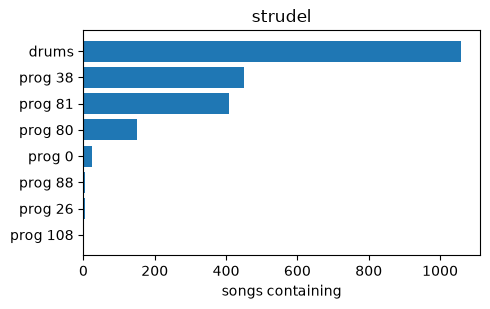

In [7]:
# Instrument-category view per dataset (top categories by song-level presence)
n = len(prog_hist)
if n:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3.2), squeeze=False)
    for ax, (ds, cnt) in zip(axes[0], sorted(prog_hist.items())):
        top = cnt.most_common(10)
        ax.barh([k for k, _ in top][::-1], [v for _, v in top][::-1])
        ax.set_title(ds); ax.set_xlabel("songs containing")
    plt.tight_layout(); plt.show()
else:
    print("nothing indexed yet")

## 4. What YourMT3+ was trained on

The checkpoint's `all_cross_final` preset mixes 10 datasets (Slakh 0.295, MIR-ST500
vocals 0.191, MusicNet 0.19, URMP/MAESTRO 0.1, ENST-drums/CMedia 0.05,
GuitarSet/IDMT-bass 0.01, EGMD 0.004). Its **only** synth timbres are Slakh's ~26
static Kontakt sample patches — no live subtractive/FM/wavetable synthesis, and
no synth bass at all. That narrow timbre exposure is the gap Restrudel fills;
full evidence in `docs/base_model_training_data.md`.

In [8]:
# Ground the augmentation summary in the actual code: list the processors.
import inspect
import utils.augment as aug
for fname in ["intra_stem_augment_processor", "drop_random_stems_from_bundle",
              "audio_random_submix_fn", "cross_stem_augment_processor",
              "combined_survival_and_stop"]:
    fn = getattr(aug, fname)
    doc = (inspect.getdoc(fn) or "").splitlines()
    print(f"- {fname}{inspect.signature(fn)}")
    if doc: print(f"    {doc[0]}")

/Users/henrik/Documents/Informatik/Master/restrudel/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- intra_stem_augment_processor(sampled_data: Dict[str, Any], random_amp_range: List[float] = [0.6, 1.2], prob: float = 0.7, update_audio_segments: bool = True, submix_audio: bool = True) -> None
    Intra_stem_augmentation
- drop_random_stems_from_bundle(sampled_data: Dict[str, Any], prob: float = 0.7) -> None
    Drop stems with a probability of `prob` from a bundle containing `note_event_segments` and 
- audio_random_submix_fn(x: numpy.ndarray, random_amp_range: Optional[List[float]] = None, mask: Optional[numpy.ndarray] = None, normalize: bool = True, dtype: numpy.dtype = <class 'numpy.float32'>) -> Tuple[numpy.ndarray, numpy.ndarray]
    Randomly submix audio. This function supports batch-wise matrix processing.
- cross_stem_augment_processor(sampled_data: Dict[str, Any], sampled_ids: numpy.ndarray, get_rand_segments_from_cache_fn: Callable, random_amp_range: List[float] = [0.6, 1.2], stem_iaug_prob: float = 0.7, stem_xaug_policy: Dict = {'max_k': 3, 'tau': 0.3, 'alpha': 1.0, 'max_

## 5. Our Strudel data

Generated locally (Node + corpus submodules) and pushed to Drive with
`scripts/dataset/sync_drive.sh push`, in the same 16 kHz format. Train-side corpus
patterns + regenerated synthetic songs feed train/validation; the held-out test
repos become the Strudel test set.

In [9]:
# Verify the Strudel data present here matches expectations.
ok = True
sd = DATA_HOME / "strudel_yourmt3_16k"
if not sd.exists():
    print("Strudel data not in Drive yet — push it from the local machine."); ok = False
else:
    per_split = {s: json.load(open(INDEX_DIR / f"strudel_{s}_file_list.json"))
                 for s in ("train", "validation", "test")}
    n = {s: len(fl) for s, fl in per_split.items()}
    hrs = {s: round(hours(fl), 2) for s, fl in per_split.items()}
    print("songs per split:", n, " hours:", hrs)
    rep = DATA_HOME / "strudel_build_report.json"
    if rep.exists():
        r = json.load(open(rep))
        print("build report: eval_fail:", len(r.get("failed_eval", [])),
              "render_fail:", len(r.get("failed_render", [])),
              "unknown sounds:", r.get("unknown_sounds", []))

songs per split: {'train': 927, 'validation': 45, 'test': 111}  hours: {'train': 4.66, 'validation': 0.23, 'test': 0.56}
build report: eval_fail: 234 render_fail: 25 unknown sounds: ['bell', 'clavisynth', 'flute', 'gm_acoustic_guitar_steel', 'gm_bandoneon', 'gm_baritone_sax', 'gm_bassoon', 'gm_cello', 'gm_choir_aahs', 'gm_church_organ', 'gm_clarinet', 'gm_distortion_guitar', 'gm_drawbar_organ', 'gm_electric_bass_finger', 'gm_electric_bass_pick', 'gm_electric_guitar_clean', 'gm_electric_guitar_jazz', 'gm_electric_guitar_muted', 'gm_electric_piano_1', 'gm_epiano1', 'gm_flute', 'gm_harmonica', 'gm_lead_1_square', 'gm_lead_2_sawtooth', 'gm_lead_6_voice', 'gm_lead_8_bass_lead', 'gm_marimba', 'gm_oboe', 'gm_ocarina', 'gm_overdriven_guitar', 'gm_pad_bowed', 'gm_pad_warm', 'gm_piano', 'gm_piccolo', 'gm_reed_organ', 'gm_string_ensemble_1', 'gm_string_ensemble_2', 'gm_synth_strings_1', 'gm_synth_strings_2', 'gm_tenor_sax', 'gm_trombone', 'gm_tuba', 'gm_vibraphone', 'gm_violin', 'gm_xylophone', '

## 6. Train / validation / test rules

1. **Repo-level test split (Track B B5).** Whole repositories
   (`strudel-songs-collection`, `strudel_trance` — held-out authors) form the
   Strudel test set; all distributions and generation use the other repos only,
   so no test author can leak in. (Replaces the old per-snippet hash split.)
2. **Strudel train/validation 95/5, never test.** The train-side corpus + any
   synthetic songs split 95/5; test is filled only by rule 1's held-out repos.
3. **Reference sets keep their canonical splits** (Slakh/MAESTRO/EGMD/NES-MDB) —
   never re-split, so numbers stay comparable to published work.

The checks below fail loudly on any leak.

In [10]:
# ---- split integrity checks (fail loudly) ---------------------------------
import hashlib, re
violations = []

def ids_of(fl):
    return {next((v for k, v in e.items() if k.endswith("_id")), None) for e in fl.values()} - {None}

# (a) within each dataset: split disjointness
by_ds = defaultdict(dict)
for fl_path in INDEX_DIR.glob("*_file_list.json"):
    ds, _, split = fl_path.stem.replace("_file_list", "").rpartition("_")
    by_ds[ds][split] = json.load(open(fl_path))
for ds, splits in by_ds.items():
    names = sorted(splits)
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            inter = ids_of(splits[a]) & ids_of(splits[b])
            if inter:
                violations.append(f"{ds}: {a} ∩ {b} = {len(inter)} songs")

ct_path = DATA_HOME / "strudel_corpus_test.json"

# (b) the strudel TEST split is exactly the held-out corpus snippets, and none
#     of them leak into strudel train/validation
if ct_path.exists() and "strudel" in by_ds:
    test_ids = {t["id"] for t in json.load(open(ct_path))["test"]}
    s_test = ids_of(by_ds["strudel"].get("test", {}))
    s_trainval = ids_of(by_ds["strudel"].get("train", {})) | ids_of(by_ds["strudel"].get("validation", {}))
    stray = s_test - test_ids
    if stray:
        violations.append(f"strudel test has {len(stray)} songs NOT in corpus_test manifest")
    leak = test_ids & s_trainval
    if leak:
        violations.append(f"CORPUS-TEST LEAK: {len(leak)} held-out snippets in strudel train/val")
    print(f"corpus test: {len(test_ids)} held-out snippets; strudel test index = {len(s_test)}; "
          f"leak into train/val = {len(leak)}")

# (c) analysis + preprocess hold out the SAME repositories (repo-level split B5)
an_path = REPO / "analysis" / "results" / "corpus_test.json"
if an_path.exists() and ct_path.exists():
    an = json.load(open(an_path)); pp = json.load(open(ct_path))
    an_repos = set(an.get("test_repos") or {i["source"] for i in an.get("items", [])})
    pp_repos = set(pp.get("test_repos") or {t.get("source") for t in pp.get("test", [])})
    if an_repos != pp_repos:
        violations.append(f"test repos differ: analysis {an_repos} vs preprocess {pp_repos}")
    print(f"held-out test repos: {sorted(an_repos)} (analysis) == {sorted(pp_repos)} (preprocess)")

# (d) provenance: no inspired song is identical to a held-out snippet
insp_yaml = REPO / "dataset" / "enhanced_all.yaml"
if ct_path.exists() and insp_yaml.exists():
    try:
        import yaml
    except ImportError:
        %pip -q install pyyaml
        import yaml
    test_hashes = {t["hash"] for t in json.load(open(ct_path))["test"]}
    doc = yaml.safe_load(open(insp_yaml))
    derived = {s["id"]: hashlib.md5(re.sub(r"\s+", "", s["code"]).encode()).hexdigest()
               for s in doc["songs"]}
    leak = {i for i, h in derived.items() if h in test_hashes}
    if leak:
        violations.append(f"inspired-from-test leak: {sorted(leak)[:5]} ...")
    print(f"inspired provenance: {len(leak)} of {len(derived)} identical to a held-out snippet")

if violations:
    raise AssertionError("SPLIT VIOLATIONS:\n  " + "\n  ".join(violations))
print("\nALL SPLIT CHECKS PASSED ✔")

corpus test: 158 held-out snippets; strudel test index = 111; leak into train/val = 0
analysis/preprocess holdout agreement: 158/158 hashes match
inspired provenance: 0 of 500 identical to a held-out snippet

ALL SPLIT CHECKS PASSED ✔


---
### Where this leaves us

- Drive holds every dataset in **one uniform, loader-ready format** with verified splits.
- Missing before a training run: per-voice **stems** for the Strudel data (unlock their
  augmentation), **real synth audio for Lakh**, and a `strudel` entry in
  `amt/src/config/data_presets.py` with sampling weights (+ a `strudel_eval` preset built
  from the corpus holdout).


## 7. Data categories at a glance (EDA)

Where every training song comes from, split by the two axes that matter for this
project. Works **now** from the repo's source-of-truth files (corpus split +
generated/enhanced YAMLs); external sets show real counts once their
`yourmt3_indexes/*_file_list.json` are built into Drive (§2), else `pending`.

- **Origin** — *Strudel-corpus* (real songs), *Strudel-generated* (our synthetic
  data), or *external* (Lakh / EGMD / MAESTRO / Slakh).
- **Domain** — *synth / electronic* (the target timbres) vs. *acoustic*
  (forgetting-mitigation reference sets).


In [ ]:
# EDA cell 1/2 — inventory every training source by category.
# No pandas: plain dicts + Counter, so it runs locally and in Colab alike.
import json
from collections import Counter

def _yaml_count(path):
    # The collated YAMLs carry a top-level `count:`; fall back to counting song
    # ids. Avoids a hard PyYAML dependency.
    for line in open(path):
        if line.startswith("count:"):
            return int(line.split(":")[1])
    return sum(1 for l in open(path) if l.lstrip().startswith("- id:"))

# rows: (domain, origin, source, split_role, songs)
inv = []

# --- Strudel: corpus (real songs) + generated (synthetic) -------------------
ct = json.load(open(REPO / "analysis/results/corpus_test.json"))
inv += [
    ("synth/electronic", "Strudel — corpus",    "corpus train-pool",        "train/val", ct["n_train_pool"]),
    ("synth/electronic", "Strudel — corpus",    "corpus held-out",          "test",      ct["n_test"]),
    ("synth/electronic", "Strudel — generated", "sampled (generate.mjs)",   "train/val", _yaml_count(REPO / "dataset/sketches_all.yaml")),
    ("synth/electronic", "Strudel — generated", "LLM-enhanced (inspired)",  "train/val", _yaml_count(REPO / "dataset/enhanced_all.yaml")),
]

# --- External sets: real counts from Drive indexes if built, else pending ---
DOMAIN = {"lakh": "synth/electronic", "egmd": "synth/electronic",
          "maestro": "acoustic", "slakh": "acoustic"}
ORIGIN = {"lakh": "Electronic — Lakh subset", "egmd": "Electronic — EGMD drums",
          "maestro": "Reference — MAESTRO piano", "slakh": "Reference — Slakh band"}
seen = Counter()
for fl_path in sorted(INDEX_DIR.glob("*_file_list.json")):
    ds, _, split = fl_path.stem.replace("_file_list", "").rpartition("_")
    if ds == "strudel":
        continue  # covered above from the source YAMLs
    n = len(json.load(open(fl_path)))
    inv.append((DOMAIN.get(ds, "acoustic"), ORIGIN.get(ds, ds), ds, split, n))
    seen[ds] += 1
for ds in ("lakh", "egmd", "maestro", "slakh"):   # keep the taxonomy visible when empty
    if not seen[ds]:
        inv.append((DOMAIN[ds], ORIGIN[ds], ds, "pending", 0))

print(f"{'domain':<18}{'origin':<26}{'source':<26}{'role':<11}{'songs':>7}")
print("-" * 88)
for d, o, s, r, n in inv:
    print(f"{d:<18}{o:<26}{s:<26}{r:<11}{n:>7}")

by_origin = Counter()
for d, o, s, r, n in inv:
    by_origin[o] += n
print("\nsongs per category (origin):")
for o, n in by_origin.most_common():
    print(f"  {n:>6}  {o}")


In [ ]:
# EDA cell 2/2 — category chart: songs per origin, colored by domain.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

agg, dom = {}, {}
for d, o, s, r, n in inv:
    agg[o] = agg.get(o, 0) + n
    dom[o] = d
labels = list(agg.keys())
vals = [agg[o] for o in labels]
colors = ["#d1495b" if dom[o] == "synth/electronic" else "#5b8def" for o in labels]

fig, ax = plt.subplots(figsize=(9, 0.55 * len(labels) + 1.4))
ax.barh(labels[::-1], vals[::-1], color=colors[::-1])
for i, v in enumerate(vals[::-1]):
    ax.text(v + max(vals + [1]) * 0.01, i, str(v), va="center", fontsize=9)
ax.set_xlabel("songs")
ax.set_title("Restrudel fine-tuning data by category")
ax.legend(handles=[Patch(color="#d1495b", label="synth / electronic (target domain)"),
                   Patch(color="#5b8def", label="acoustic (forgetting-mitigation)")],
          loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

pending = [s for d, o, s, r, n in inv if r == "pending"]
if pending:
    print("Pending download (run §2 in Colab with Drive mounted):", ", ".join(pending))
